## m7 — Up Rebalancing, Round 2

m6 results showed that **augmentation diversity** (m6d) is the
effective lever for Up F1 — gradient-side interventions (aggressive
weights, focal loss) and oversampling alone hit a ceiling at 0.74.

| m6 Experiment | Up F1 | Up Precision | Up Recall |
|---------------|-------|-------------|----------|
| m5c baseline  | 0.74  | —           | —        |
| m6a (6× weight) | 0.71 | 0.72 | 0.71 |
| m6b (focal loss) | 0.74 | 0.69 | 0.79 |
| m6c (oversample 8×) | 0.71 | 0.77 | 0.66 |
| **m6d (heavy Up aug)** | **0.76** | **0.81** | **0.72** |

m6d won on precision; m6b showed recall potential. This notebook
tests two combinations:

| Experiment | Strategy |
|------------|----------|
| m7a | m6d heavy Up augmentation + m6b focal loss |
| m7b | Even more aggressive Up augmentation (random erasing, wider jitter, Gaussian noise) |

## Setup

In [1]:
# Install WebDataset
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.1 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Verify GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# Imports

import os, glob, time, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# Paths

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"
DRIVE_DIR       = "/content/drive/MyDrive/210"

print(f"TAR_DIR:     {TAR_DIR}")
print(f"LABELS_CSV:  {LABELS_CSV}")
print(f"GEO_PARQUET: {GEO_PARQUET}")

TAR_DIR:     /content/gaze_wds_balanced
LABELS_CSV:  /content/drive/MyDrive/210/gaze_labels.csv
GEO_PARQUET: /content/drive/MyDrive/210/geo_features_v1.parquet


In [6]:
# Copy tars to local Colab disk

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# Verify files

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Labels CSV: {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True


In [8]:
# Load labels — 4-class lookup (Straight dropped)

df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

# filter out Straight
label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}
label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}

print(f"Label lookup (4-class): {len(label_lookup_4)} entries")
print(f"Dropped: {len(label_lookup) - len(label_lookup_4)} Straight samples")

Loaded 849131 labeled frames
Label lookup (4-class): 602467 entries
Dropped: 246664 Straight samples


In [9]:
# Load geo features

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# neutral default for missing samples
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

# coverage check
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
print(f"Geo coverage: {matched}/{len(label_lookup_4)} ({100*matched/len(label_lookup_4):.1f}%)")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries
Geo coverage: 192519/602467 (32.0%)


In [10]:
# Standard image transforms (non-Up classes)

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Standard transforms defined")

Standard transforms defined


In [11]:
# GazeNetM5 model definition (identical across all experiments)

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # eye CNN — shared weights for left and right
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # face CNN
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # geometric feature branch
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # FC classifier: 4608*2 (eyes) + 2304 (face) + 64 (geo) = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
Parameters: 6,586,820


## Shared Training & Evaluation Functions

In [12]:
# Focal loss (from m6b — reused in m7a)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        """
        Args:
            alpha: per-class weight tensor, shape (num_classes,).
            gamma: focal modulation exponent. 0 = standard CE.
            label_smoothing: standard label smoothing factor.
            reduction: 'mean' or 'sum' or 'none'.
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )

        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

print("FocalLoss defined")

FocalLoss defined


In [13]:
# Up-targeted augmentation dataset builder (from m6d — reused in both m7a and m7b)

def make_dataset_4class_up_targeted_aug(
    tar_urls,
    eye_transform_standard, face_transform_standard,
    eye_transform_up, face_transform_up,
    shuffle=True
):
    """4-class pipeline with class-conditional augmentation."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        label_idx = label_map_4[label_str]

        # pick transform set based on class
        if label_idx == 0:  # Up
            e_tfm = eye_transform_up
            f_tfm = face_transform_up
        else:
            e_tfm = eye_transform_standard
            f_tfm = face_transform_standard

        left_eye = e_tfm(left_eye)
        right_eye = e_tfm(right_eye)
        face = f_tfm(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class_up_targeted_aug defined")

make_dataset_4class_up_targeted_aug defined


In [14]:
# Training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    n_batches = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        n_batches = batch_idx + 1

        if n_batches % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta = (elapsed / n_batches) * (7000 - n_batches) / 60
            print(f"  Batch {n_batches}/~7000 - Loss: {loss.item():.4f} - ETA: {eta:.1f} min")

    return total_loss / n_batches, 100 * correct / total


def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            n_batches += 1

    return total_loss / n_batches, 100 * correct / total

print("train_one_epoch / evaluate defined")

train_one_epoch / evaluate defined


In [15]:
# Training curves plotter

TEAL_DARK  = '#0D7377'
TEAL_LIGHT = '#45C4B0'

def plot_training_curves(history, experiment_name):
    """Three-panel training curves: loss, accuracy, gap."""
    epochs = range(1, len(history['train_losses']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # loss
    axes[0].plot(epochs, history['train_losses'], 'o-', color=TEAL_DARK,  label='Train Loss')
    axes[0].plot(epochs, history['val_losses'],   'o-', color=TEAL_LIGHT, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss', fontweight='bold', color=TEAL_DARK)
    axes[0].legend()

    # accuracy
    axes[1].plot(epochs, history['train_accs'], 'o-', color=TEAL_DARK,  label='Train Acc')
    axes[1].plot(epochs, history['val_accs'],   'o-', color=TEAL_LIGHT, label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy', fontweight='bold', color=TEAL_DARK)
    axes[1].legend()

    # train-val gap
    gaps = [t - v for t, v in zip(history['train_accs'], history['val_accs'])]
    axes[2].plot(epochs, gaps, 'o-', color=TEAL_DARK)
    axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy Gap (%)')
    axes[2].set_title('Train-Val Accuracy Gap', fontweight='bold', color=TEAL_DARK)

    plt.suptitle(f'{experiment_name} — Training Curves',
                 fontsize=14, fontweight='bold', color=TEAL_DARK)
    plt.tight_layout()
    plt.show()

print("plot_training_curves defined")

plot_training_curves defined


In [16]:
# Full experiment runner with training summary and curves

def run_experiment(experiment_name, model, train_loader, val_loader,
                   criterion, optimizer, scheduler, device,
                   num_epochs=20, patience=6):
    """
    Full training loop with early stopping.
    Saves best checkpoint, prints training summary, plots curves.
    """
    checkpoint_path = f"{DRIVE_DIR}/{experiment_name}.pth"
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_val_epoch = 0
    best_acc_epoch = 0
    patience_counter = 0

    history = {
        'train_losses': [], 'val_losses': [],
        'train_accs': [], 'val_accs': [],
    }

    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Checkpoint: {checkpoint_path}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        history['train_accs'].append(train_acc)
        history['val_accs'].append(val_acc)

        scheduler.step(val_loss)

        # track best val accuracy (separate from best loss)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_acc_epoch = epoch + 1

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Gap: {train_acc - val_acc:.2f}%")

        # checkpoint best model (by val loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_epoch = epoch + 1
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Saved best model (val_loss={val_loss:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    # training summary
    total_epochs = len(history['train_losses'])
    print(f"\n{'='*50}")
    print(f"Training Summary")
    print(f"{'='*50}")
    print(f"Total epochs completed: {total_epochs}")
    print(f"Best validation loss: {best_val_loss:.4f} (Epoch {best_val_epoch})")
    print(f"Best validation accuracy: {best_val_acc:.2f}% (Epoch {best_acc_epoch})")
    print(f"Final train accuracy: {history['train_accs'][-1]:.2f}%")
    print(f"Final val accuracy: {history['val_accs'][-1]:.2f}%")
    print(f"Final train-val gap: {history['train_accs'][-1] - history['val_accs'][-1]:.2f}%")
    print(f"{'='*50}")

    # plot training curves
    plot_training_curves(history, experiment_name)

    return history

print("run_experiment defined")

run_experiment defined


In [17]:
# Test evaluation, confusion matrix, and classification report

LABEL_NAMES = ['Up', 'Down', 'Left', 'Right']
TEAL_CMAP = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377']
)

# m5c baseline for delta comparison
M5C_UP_F1 = 0.74

def test_and_report(experiment_name, model, test_loader, device):
    """
    Load best checkpoint, run test eval, print report with m5c delta,
    plot confusion matrix.
    """
    checkpoint_path = f"{DRIVE_DIR}/{experiment_name}.pth"
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=TEAL_CMAP,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, linecolor='white')
    plt.xlabel('Predicted', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.title(f'{experiment_name} — Test Confusion Matrix',
              fontweight='bold', color='#0D7377', fontsize=13)
    plt.tight_layout()
    plt.show()

    # classification report
    print(f"\n{experiment_name} Test Performance")
    print("=" * 50)
    print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

    # quick delta vs m5c
    acc = 100 * accuracy_score(all_labels, all_preds)
    f1s = f1_score(all_labels, all_preds, average=None, labels=[0, 1, 2, 3])
    print(f"vs m5c baseline:")
    print(f"  Up F1: {f1s[0]:.3f}  (\u0394 {f1s[0] - M5C_UP_F1:+.3f})")
    print(f"  Overall Acc: {acc:.2f}%")

    return all_preds, all_labels

print("test_and_report defined")

test_and_report defined


In [18]:
# Val/test loaders — fixed across all experiments

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):
    """Standard 4-class WebDataset pipeline."""

    def filter_and_transform(sample):
        key = sample["__key__"]
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )
    return dataset

val_dataset  = make_dataset_4class(val_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset = make_dataset_4class(test_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)

val_loader  = wds.WebLoader(val_dataset,  batch_size=32, num_workers=2, pin_memory=True)
test_loader = wds.WebLoader(test_dataset, batch_size=32, num_workers=2, pin_memory=True)

print("Val/test loaders ready")

Val/test loaders ready


---

## Experiment m7a — Heavy Up Augmentation + Focal Loss

Combines the two most promising m6 results:
- **m6d's heavy photometric augmentation** on Up samples (precision=0.81)
- **m6b's focal loss** (recall=0.79)

m6d sharpened the Up boundary; m6b pushed the model to try harder
on uncertain samples near that boundary. Together, the hypothesis is
that the model can try harder (focal loss) *and* have a cleaner
feature space to work with (augmentation diversity).

In [19]:
# m7a Up-heavy transforms (same as m6d)

eye_transform_up_m7a = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.05),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_up_m7a = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.05),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("m7a Up-heavy transforms defined (same as m6d)")

m7a Up-heavy transforms defined (same as m6d)


In [20]:
# m7a setup — m6d augmentation + m6b focal loss

model_m7a = GazeNetM5(num_classes=4).to(device)

# sqrt inverse frequency weights (same as m5c/m6d)
train_counts = [4247, 51514, 42872, 40888]
total = sum(train_counts)
n_classes = 4
weights_sqrt = [math.sqrt(total / (n_classes * c)) for c in train_counts]
weights_sqrt_tensor = torch.tensor(weights_sqrt, dtype=torch.float32).to(device)

# focal loss with class weights
criterion_m7a = FocalLoss(
    alpha=weights_sqrt_tensor,
    gamma=2.0,
    label_smoothing=0.1
)

optimizer_m7a = torch.optim.Adam(model_m7a.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m7a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m7a, mode='min', patience=3, factor=0.5
)

# class-conditional augmentation loader
train_dataset_m7a = make_dataset_4class_up_targeted_aug(
    train_tar_urls,
    eye_transform_standard=eye_transform_aug,
    face_transform_standard=face_transform_aug,
    eye_transform_up=eye_transform_up_m7a,
    face_transform_up=face_transform_up_m7a,
    shuffle=True
)
train_loader_m7a = wds.WebLoader(
    train_dataset_m7a, batch_size=32, num_workers=2, pin_memory=True
)

print(f"m7a ready — m6d heavy aug + focal loss (gamma=2.0)")
print(f"Class weights: {dict(zip(LABEL_NAMES, weights_sqrt))}")

m7a ready — m6d heavy aug + focal loss (gamma=2.0)
Class weights: {'Up': 2.865818382037267, 'Down': 0.8228622856293477, 'Left': 0.9019924918250851, 'Right': 0.9236168780131793}



  EXPERIMENT: m7a
  Checkpoint: /content/drive/MyDrive/210/m7a.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.3668 - ETA: 13.3 min
  Batch 2000/~7000 - Loss: 0.1863 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.1886 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.2189 - ETA: 6.2 min
  Train Loss: 0.2305 | Train Acc: 83.18%
  Val Loss:   0.1548 | Val Acc:   89.42%
  Gap: -6.24%
  Saved best model (val_loss=0.1548)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.1856 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.0477 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.1122 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.0574 - ETA: 6.2 min
  Train Loss: 0.1193 | Train Acc: 91.63%
  Val Loss:   0.1351 | Val Acc:   90.23%
  Gap: 1.40%
  Saved best model (val_loss=0.1351)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.0552 - ETA: 13.4 min
  Batch 2000/~7000 - Loss: 0.0307 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.0564 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.0395 - ETA: 6.3 min
  Train Loss: 0.0912 | Train Acc: 93.

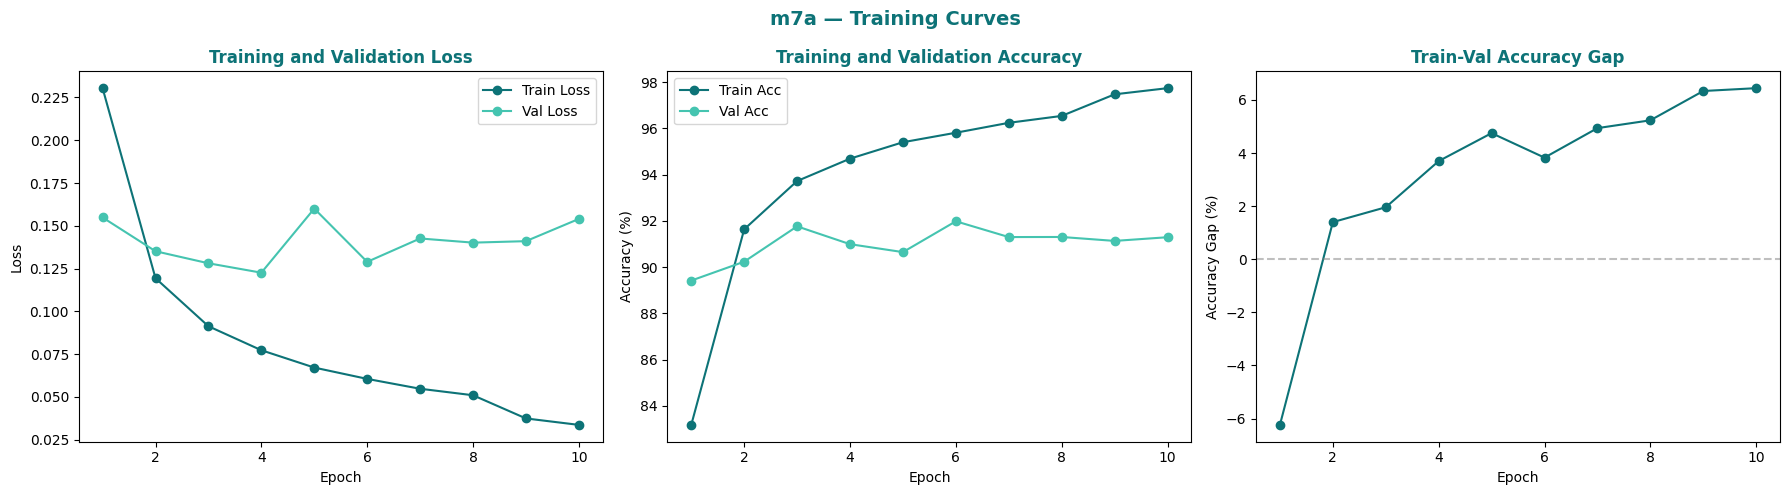

In [21]:
# m7a training

history_m7a = run_experiment(
    experiment_name='m7a',
    model=model_m7a,
    train_loader=train_loader_m7a,
    val_loader=val_loader,
    criterion=criterion_m7a,
    optimizer=optimizer_m7a,
    scheduler=scheduler_m7a,
    device=device,
)

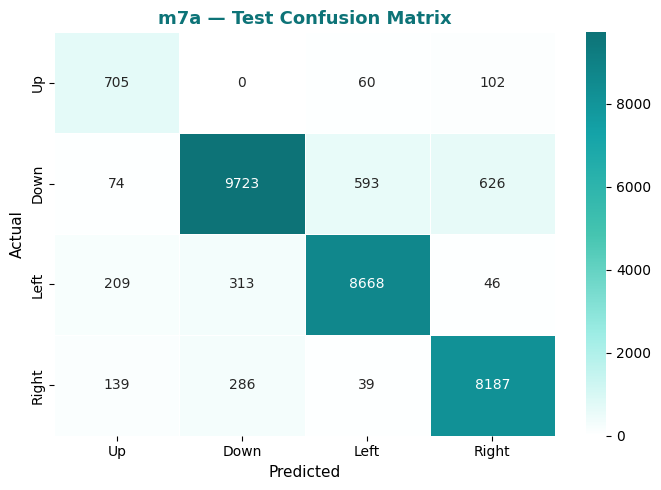


m7a Test Performance
              precision    recall  f1-score   support

          Up       0.63      0.81      0.71       867
        Down       0.94      0.88      0.91     11016
        Left       0.93      0.94      0.93      9236
       Right       0.91      0.95      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.85      0.90      0.87     29770
weighted avg       0.92      0.92      0.92     29770

vs m5c baseline:
  Up F1: 0.707  (Δ -0.033)
  Overall Acc: 91.65%


In [22]:
# m7a test evaluation

preds_m7a, labels_m7a = test_and_report('m7a', model_m7a, test_loader, device)

---

## Experiment m7b — Maximum Up Augmentation

Pushes the m6d augmentation further with three additions:

- **Random erasing** — masks out a random rectangle of the image,
  forcing the model to rely on different spatial regions rather than
  fixating on one part of the eye/face. This is a fundamentally
  different kind of diversity than photometric jitter (spatial
  masking vs. color variation).
- **Wider color jitter** — brightness/contrast up to 0.7.
- **Gaussian noise** — added as a custom transform after ToTensor,
  simulates camera sensor noise at varying levels.

No spatial transforms (flips, rotation, perspective) — those would
break the iris-position and head-pose signals the geo features
depend on.

Uses standard m5c sqrt inverse frequency class weights (not focal loss)
to isolate the augmentation variable from m7a.

In [23]:
# Gaussian noise transform (custom)
#
# Applied after ToTensor (operates on normalized tensor).
# Std drawn uniformly from [0, max_std] per sample so the
# model sees a range of noise levels.

class GaussianNoise:
    def __init__(self, max_std=0.05):
        self.max_std = max_std

    def __call__(self, tensor):
        # random noise level per sample
        std = torch.rand(1).item() * self.max_std
        noise = torch.randn_like(tensor) * std
        return tensor + noise

print("GaussianNoise transform defined")

GaussianNoise transform defined


In [24]:
# m7b maximum Up transforms
#
# Builds on m6d and adds:
#   - wider color jitter (0.7 brightness/contrast vs 0.5)
#   - random erasing (masks a random rectangle after normalization)
#   - gaussian noise (simulates camera sensor noise)

eye_transform_up_m7b = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    # wider photometric jitter than m6d
    transforms.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.5, hue=0.08),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    # gaussian noise (after tensor conversion)
    GaussianNoise(max_std=0.05),
    # random erasing — masks a patch, forces model to use different regions
    transforms.RandomErasing(p=0.3, scale=(0.05, 0.15), ratio=(0.5, 2.0), value='random'),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_up_m7b = transforms.Compose([
    transforms.ToPILImage(),
    # wider photometric jitter than m6d
    transforms.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.5, hue=0.08),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    # gaussian noise (after tensor conversion)
    GaussianNoise(max_std=0.05),
    # random erasing — larger scale range for 112x112 face crops
    transforms.RandomErasing(p=0.3, scale=(0.05, 0.20), ratio=(0.5, 2.0), value='random'),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("m7b maximum Up transforms defined")
print("  New vs m6d: wider jitter, random erasing, gaussian noise")

m7b maximum Up transforms defined
  New vs m6d: wider jitter, random erasing, gaussian noise


In [25]:
# m7b setup — maximum augmentation + standard sqrt inverse frequency weights

model_m7b = GazeNetM5(num_classes=4).to(device)

# standard class weights (isolating the augmentation variable from m7a)
criterion_m7b = nn.CrossEntropyLoss(
    weight=weights_sqrt_tensor,
    label_smoothing=0.1
)

optimizer_m7b = torch.optim.Adam(model_m7b.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m7b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m7b, mode='min', patience=3, factor=0.5
)

# class-conditional augmentation loader
train_dataset_m7b = make_dataset_4class_up_targeted_aug(
    train_tar_urls,
    eye_transform_standard=eye_transform_aug,
    face_transform_standard=face_transform_aug,
    eye_transform_up=eye_transform_up_m7b,
    face_transform_up=face_transform_up_m7b,
    shuffle=True
)
train_loader_m7b = wds.WebLoader(
    train_dataset_m7b, batch_size=32, num_workers=2, pin_memory=True
)

print("m7b ready — maximum Up augmentation + sqrt inv freq weights")

m7b ready — maximum Up augmentation + sqrt inv freq weights



  EXPERIMENT: m7b
  Checkpoint: /content/drive/MyDrive/210/m7b.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.8178 - ETA: 13.4 min
  Batch 2000/~7000 - Loss: 0.6593 - ETA: 11.1 min
  Batch 3000/~7000 - Loss: 0.5847 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.5920 - ETA: 6.3 min
  Train Loss: 0.7769 | Train Acc: 85.89%
  Val Loss:   0.7809 | Val Acc:   87.72%
  Gap: -1.82%
  Saved best model (val_loss=0.7809)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.6509 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.5593 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.6069 - ETA: 8.7 min
  Batch 4000/~7000 - Loss: 0.5690 - ETA: 6.3 min
  Train Loss: 0.6255 | Train Acc: 94.11%
  Val Loss:   0.7285 | Val Acc:   89.87%
  Gap: 4.25%
  Saved best model (val_loss=0.7285)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.5692 - ETA: 13.4 min
  Batch 2000/~7000 - Loss: 0.5587 - ETA: 11.1 min
  Batch 3000/~7000 - Loss: 0.5435 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.7109 - ETA: 6.3 min
  Train Loss: 0.5883 | Train Acc: 95.

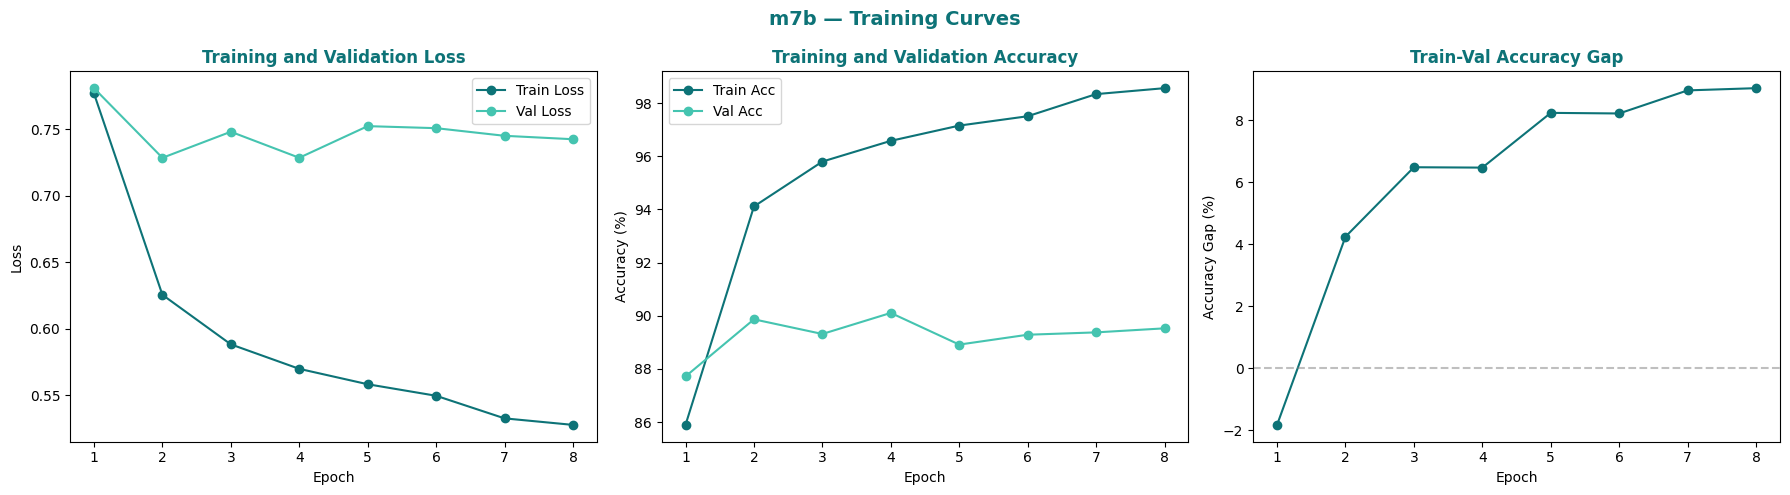

In [26]:
# m7b training

history_m7b = run_experiment(
    experiment_name='m7b',
    model=model_m7b,
    train_loader=train_loader_m7b,
    val_loader=val_loader,
    criterion=criterion_m7b,
    optimizer=optimizer_m7b,
    scheduler=scheduler_m7b,
    device=device,
)

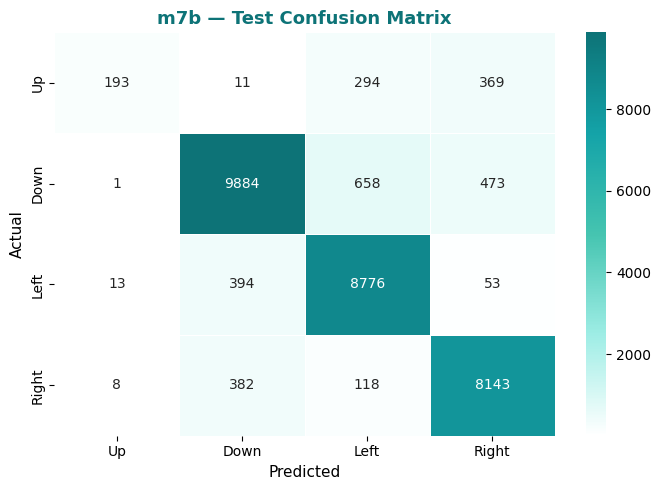


m7b Test Performance
              precision    recall  f1-score   support

          Up       0.90      0.22      0.36       867
        Down       0.93      0.90      0.91     11016
        Left       0.89      0.95      0.92      9236
       Right       0.90      0.94      0.92      8651

    accuracy                           0.91     29770
   macro avg       0.90      0.75      0.78     29770
weighted avg       0.91      0.91      0.90     29770

vs m5c baseline:
  Up F1: 0.357  (Δ -0.383)
  Overall Acc: 90.68%


In [27]:
# m7b test evaluation

preds_m7b, labels_m7b = test_and_report('m7b', model_m7b, test_loader, device)

---

## Experiment Comparison

In [28]:
# Full comparison table — m5c through m7

results = {
    'm5c (baseline)': {'acc': 92.1,  'up_f1': 0.74,  'up_p': None,  'up_r': None},
    'm6d (heavy aug)': {'acc': 92.0, 'up_f1': 0.76,  'up_p': 0.81,  'up_r': 0.72},
}

for name, preds, labels in [
    ('m7a (aug+focal)', preds_m7a, labels_m7a),
    ('m7b (max aug)',   preds_m7b, labels_m7b),
]:
    try:
        acc = 100 * accuracy_score(labels, preds)
        f1s = f1_score(labels, preds, average=None, labels=[0,1,2,3])
        report = classification_report(labels, preds, target_names=LABEL_NAMES, output_dict=True)
        results[name] = {
            'acc': acc,
            'up_f1': f1s[0],
            'up_p': report['Up']['precision'],
            'up_r': report['Up']['recall'],
        }
    except NameError:
        print(f"  {name}: not yet run, skipping")

# print table
print(f"{'Experiment':<22s} {'Acc':>7s} {'Up F1':>7s} {'Up P':>7s} {'Up R':>7s} {'Δ F1':>7s}")
print("-" * 56)
for name, m in results.items():
    delta = f"{m['up_f1'] - M5C_UP_F1:+.3f}" if name != 'm5c (baseline)' else '   --'
    p_str = f"{m['up_p']:.3f}" if m['up_p'] is not None else '   --'
    r_str = f"{m['up_r']:.3f}" if m['up_r'] is not None else '   --'
    print(f"{name:<22s} {m['acc']:>6.1f}% {m['up_f1']:>7.3f} {p_str:>7s} {r_str:>7s} {delta:>7s}")

Experiment                 Acc   Up F1    Up P    Up R    Δ F1
--------------------------------------------------------
m5c (baseline)           92.1%   0.740      --      --      --
m6d (heavy aug)          92.0%   0.760   0.810   0.720  +0.020
m7a (aug+focal)          91.6%   0.707   0.626   0.813  -0.033
m7b (max aug)            90.7%   0.357   0.898   0.223  -0.383


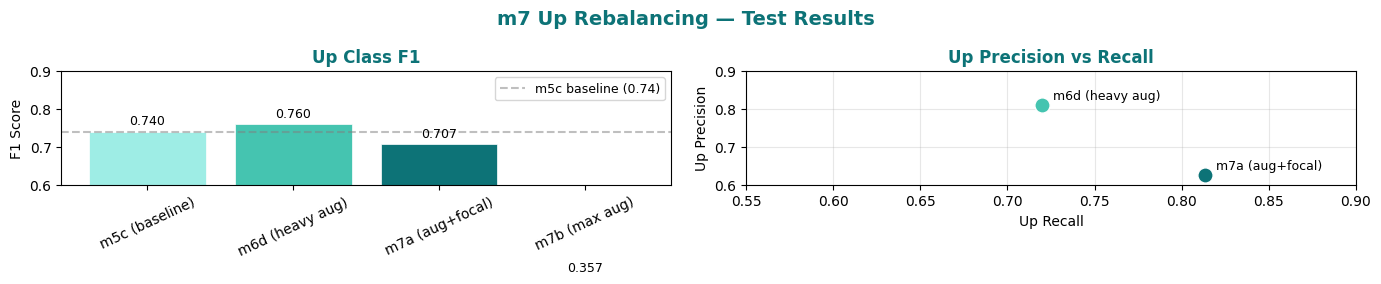

In [29]:
# Visual comparison — Up precision vs recall scatter + F1 bars

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
up_f1s = [results[n]['up_f1'] for n in names]

# assign colors: baseline lightest, m6d medium, m7 experiments darkest
bar_colors = ['#9EEDE5', '#45C4B0'] + ['#0D7377'] * (len(names) - 2)

# Up F1 bars
bars = axes[0].bar(names, up_f1s, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Up Class F1', fontweight='bold', color='#0D7377')
axes[0].set_ylim(0.6, 0.9)
axes[0].axhline(y=M5C_UP_F1, color='gray', linestyle='--', alpha=0.5, label=f'm5c baseline ({M5C_UP_F1})')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, up_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=25)

# Up precision vs recall scatter
for i, name in enumerate(names):
    m = results[name]
    if m['up_p'] is not None and m['up_r'] is not None:
        axes[1].scatter(m['up_r'], m['up_p'], color=bar_colors[i], s=120, zorder=3, edgecolors='white')
        axes[1].annotate(name, (m['up_r'], m['up_p']),
                         textcoords='offset points', xytext=(8, 4), fontsize=9)

axes[1].set_xlabel('Up Recall')
axes[1].set_ylabel('Up Precision')
axes[1].set_title('Up Precision vs Recall', fontweight='bold', color='#0D7377')
axes[1].set_xlim(0.55, 0.90)
axes[1].set_ylim(0.60, 0.90)
axes[1].grid(True, alpha=0.3)

plt.suptitle('m7 Up Rebalancing — Test Results',
             fontsize=14, fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

In [30]:
# Save raw training histories for your spreadsheet

for name, hist in [('m7a', history_m7a), ('m7b', history_m7b)]:
    try:
        print(f"\n--- {name} ---")
        print(f"train_losses_{name} = {hist['train_losses']}")
        print(f"val_losses_{name} = {hist['val_losses']}")
        print(f"train_acc_{name} = {hist['train_accs']}")
        print(f"val_acc_{name} = {hist['val_accs']}")
    except NameError:
        print(f"  {name}: not yet run")


--- m7a ---
train_losses_m7a = [0.23045147837320548, 0.11932048467396869, 0.09124332582842874, 0.07721349185313862, 0.06707570651507466, 0.06045173251410065, 0.05468911553383458, 0.05089354640770062, 0.03733290805549392, 0.033560683277302765]
val_losses_m7a = [0.15484605377057722, 0.13510143703226615, 0.12805923225622365, 0.12255257397167346, 0.16003158291997677, 0.12888742293939737, 0.14256420796743857, 0.14013058286494165, 0.14099127292694189, 0.1539926365935769]
train_acc_m7a = [83.17887629819167, 91.63280079701264, 93.71994180087586, 94.6875380767053, 95.39782541696232, 95.80851628070326, 96.23712559399661, 96.53528859454849, 97.46919818521943, 97.735107976577]
val_acc_m7a = [89.41729722084719, 90.23407114065483, 91.76154444523019, 90.99073615727318, 90.64776182731066, 91.98076515097942, 91.29835230888905, 91.30188812672371, 91.13216887065978, 91.29128067321972]

--- m7b ---
train_losses_m7b = [0.7768536797632621, 0.6255411736545856, 0.5883024747124016, 0.5698994848329632, 0.55832